# Breast Cancer Transcriptomic Analysis

## Exploring Gene Expression Across Breast Cancer Molecular Subtypes

### Objective

Breast cancer is a heterogeneous disease consisting of molecularly
distinct subtypes with different biological characteristics.

This project investigates whether gene-expression profiles can
distinguish breast cancer subtypes using publicly available
transcriptomic data from the NCBI Gene Expression Omnibus (GEO).

Dataset: GSE45827

The processed Series Matrix file was used.

The analysis explores:

- gene-expression patterns across breast cancer subtypes
- dimensionality reduction using PCA
- subtype-associated gene-expression differences
- expression of biologically relevant breast cancer genes
- whether gene-expression profiles can be used to classify tumour subtype

What the design actually involves:

- The study has three broad kinds of material:

* Primary breast tumour samples — tissue taken during surgery before treatment. These tumours are classified into the four subtypes of breast cancer: 41 samples of triple-negative (TN), 30 samples of HER2, 29 samples of Luminal A and 30 samples of Luminal B.
* 11 Normal breast tissue samples — included so expression in cancerous tissue can be compared with non-cancerous breast tissue.
* 14 Breast cancer cell lines — cancer cells maintained and grown in the laboratory, included as another type of breast-cancer model.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing libraries to help visualise and analyse the dataset (below)

In [23]:
import pandas as pd #working with structured/tabular data
import numpy as np #for numerical calculations
import matplotlib.pyplot as plt #for data visualisations

from sklearn.preprocessing import StandardScaler #adjusting different numerical features onto a similiar measuring scale
from sklearn.decomposition import PCA #Principal Component Analysis simplifies/summarises lots of variables so we can see the main patterns

print("Libraries loaded successfully.")

Libraries loaded successfully.


Download the dataset from the url (below)

In [24]:
import urllib.request

url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/matrix/GSE45827_series_matrix.txt.gz"

filename = "GSE45827_series_matrix.txt.gz"

urllib.request.urlretrieve(url, filename)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


Inspecting the file to see its contents (below)

In [25]:
import gzip #lets Python work with the compressed zip file

with gzip.open(filename, "rt") as file:
    for i in range(20):
        print(file.readline().strip()) #only inspects the first 20 lines of the file

!Series_title	"Expression data from Breast cancer subtypes"
!Series_geo_accession	"GSE45827"
!Series_status	"Public on Mar 24 2016"
!Series_submission_date	"Apr 05 2013"
!Series_last_update_date	"Mar 25 2019"
!Series_pubmed_id	"27006338"
!Series_summary	"Expression data from Breast cancer subtypes"
!Series_overall_design	"In a cohort study of primary invasive breast cancer (41 TN, 30 HER2, 29 Luminal A and 30 Luminal B) as well as 11 normal tissues samples and 14 cell lines , we obtained a tumor specimen at surgery before any patient treatment. Total RNA was extracted from all samples and the whole transcriptome was quantified with Affymetrix U133 Plus 2.0 Chips."
!Series_type	"Expression profiling by array"
!Series_contributor	"Tina,,Gruosso"
!Series_contributor	"Yann,,Kieffer"
!Series_contributor	"Thierry,,Dubois"
!Series_contributor	"Fatima,,Mechta-Grigoriou"
!Series_sample_id	"GSM1116084 GSM1116085 GSM1116086 GSM1116087 GSM1116088 GSM1116089 GSM1116090 GSM1116091 GSM1116092 GSM1116

Search the gzip file to find which line the expression matrix starts on (below)

In [26]:
with gzip.open(filename, "rt") as file:
    for line_number, line in enumerate(file):
        if "series_matrix_table_begin" in line:
            print("Expression matrix starts at line:", line_number)
            print(line.strip())
            break #stop at line where the expression matrix starts

Expression matrix starts at line: 67
!series_matrix_table_begin


Inspecting the expression matrix (below)

In [27]:

with gzip.open(filename, "rt") as file:
    lines = file.readlines()

for line in lines[68:73]:
    print(line[:500])

"ID_REF"	"GSM1116084"	"GSM1116085"	"GSM1116086"	"GSM1116087"	"GSM1116088"	"GSM1116089"	"GSM1116090"	"GSM1116091"	"GSM1116092"	"GSM1116093"	"GSM1116094"	"GSM1116095"	"GSM1116096"	"GSM1116097"	"GSM1116098"	"GSM1116099"	"GSM1116100"	"GSM1116101"	"GSM1116102"	"GSM1116103"	"GSM1116104"	"GSM1116105"	"GSM1116106"	"GSM1116107"	"GSM1116108"	"GSM1116109"	"GSM1116110"	"GSM1116111"	"GSM1116112"	"GSM1116113"	"GSM1116114"	"GSM1116115"	"GSM1116116"	"GSM1116117"	"GSM1116118"	"GSM1116119"	"GSM1116120"	"GSM111612
"1007_s_at"	9.47065	9.6744	10.208	10.1142	11.1636	10.0069	9.53932	9.00187	6.54074	10.3551	10.0378	10.6458	10.4495	8.37233	9.48393	10.1414	10.2397	8.60988	9.30953	10.1158	10.2282	10.9337	10.4501	10.774	9.09858	9.82919	9.76393	9.71049	9.63422	9.32985	9.13237	10.2123	10.6347	10.1965	10.2429	9.6089	9.3268	10.5106	10.5697	10.1473	8.34806	9.40561	10.5641	9.73944	11.1704	9.72613	10.9106	8.6077	10.3804	10.3811	9.81215	9.46771	9.67632	11.0246	10.7265	9.75026	10.0241	10.3423	11.1542	11.0368	9.45143	10.43

The output (above) gives us the "ID_REF" which refers to the Affymetrix probe-set identifier (a unique alphanumeric label that measures the level of expression of a gene/transcript) while each GSM column represents one of the 155 biological samples. So the data tells us the level of expression of the specific gene/transcript in a biological sample. The data is processed log2-scale expression values (not the number of molecules etc.), it's the intensity of the expression.

The processed gene expression matrix needs cleaning/extracting and loaded onto a DataFrame, as we only need the probe ID and GS biological samples expression data, not metadata.

In [28]:
expression_data = pd.read_csv( #using pandas to load tabular data into a DataFrame
    filename,
    sep="\t", #values in data isn't separated by commas but tabs, so treat each tab as a column
    comment="!", #ignore the metadata lines (e.g. lines before expression data that start with !)
    index_col=0, #use first column as row labels (e.g. first column is ID_REF)
    compression="gzip" #tells pandas that this file is gzip compressed
)

print("Expression matrix shape:", expression_data.shape) #.shape tells us the dimensions of the DataFrame (e.g. number of rows and number of columns and we know that each row that starts with GS is a biological sample so it's 155)

Expression matrix shape: (29873, 155)


We now can inspect the DataFrame to see if it actually gave us the data we wanted, using pandas .head function

In [29]:
expression_data.head()

,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,10.35510,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,9.45426,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,3.85652,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,4.79560,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,3.27900,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


We can find out whether there are any missing values in the table and whether pandas correctly identified the 155 sample columns as numerical data rather than text (below).

In [30]:
print("\nMissing values:", expression_data.isnull().sum().sum())

print("\nData types:")
print(expression_data.dtypes.value_counts())


Missing values: 0

Data types:
float64    155
Name: count, dtype: int64


The output (above) tells us there are missing data in the DataFrame and that all 155 biological samples are float type (meaning all are decimal numerical values).

Right now we don't have any subtype information in the DataFrame so we need to create sample labels/metadata, for example we know that this study contains subtypes TN, HER2, Luminal A, Luminal B, normal tissue and cell lines. But we don't know which of these biological samples have these subtypes, so we need to include that using the metadata.

In [31]:
with gzip.open(filename, "rt") as file:
    for line in file:
        if line.startswith("!Sample_"):
            print(line[:1000])

!Sample_title	"Basal Sample1 rep1"	"Basal Sample2 rep1-2"	"Her2 Sample3 rep1"	"Basal Sample4 rep1-2"	"Her2 Sample5 rep1-2"	"Her2 Sample6 rep1-2"	"Basal Sample7 rep1"	"Basal Sample8 rep1-2"	"Basal Sample9 rep1"	"Basal Sample10 rep1-2"	"Basal Sample11 rep1"	"Her2 Sample12 rep1-2"	"Her2 Sample13 rep1"	"Her2 Sample14 rep1"	"Her2 Sample15 rep1"	"Basal Sample16 rep1-2"	"Her2 Sample17 rep1"	"Basal Sample18 rep1"	"Basal Sample19 rep1-2"	"Her2 Sample20 rep1"	"Her2 Sample21 rep1-2"	"Her2 Sample22 rep1"	"Basal Sample23 rep1-2"	"Her2 Sample24 rep1-2"	"Basal Sample25 rep1"	"Basal Sample26 rep1"	"Basal Sample27 rep1"	"Basal Sample28 rep1"	"Basal Sample29 rep1-2"	"Basal Sample30 rep1"	"Basal Sample31 rep1"	"Basal Sample32 rep1"	"Her2 Sample33 rep1"	"Her2 Sample34 rep1-2"	"Basal Sample35 rep1-2"	"Basal Sample36 rep1-2"	"Basal Sample37 rep1-2"	"Her2 Sample38 rep1"	"Her2 Sample39 rep1-2"	"Her2 Sample40 rep1"	"Basal Sample41 rep1"	"Basal Sample42 rep1"	"Her2 Sample43 rep1-2"	"Her2 Sample44 rep1"	"Basal S

Next, creating the metadata table by extracting them from the GEO file.

In [32]:
sample_ids = None
sample_subtypes = None

with gzip.open(filename, "rt") as file:
    for line in file:

        if line.startswith("!Sample_geo_accession"): #finds the sample IDs
            sample_ids = line.strip().split("\t")[1:] #position 0 would give the name of the column e.g. Sample Geo Accession, but we want the data below this

        elif line.startswith("!Sample_characteristics_ch1") and "tumor subtype:" in line: #finds the subtype row
            sample_subtypes = line.strip().split("\t")[1:]

Cleaning the data.

In [33]:
sample_ids = [x.strip('"') for x in sample_ids] #using list comprehension to remove the quotation marks and label texts

sample_subtypes = [
    x.strip('"').replace("tumor subtype: ", "")
    for x in sample_subtypes
]

Creating metadata DataFrame

In [34]:
metadata = pd.DataFrame({ #create a table called metadata with a column containing the sample IDs and another containing the subtypes
    "Sample": sample_ids,
    "Subtype": sample_subtypes
})

metadata.head()

,Sample,Subtype
0,GSM1116084,Basal
1,GSM1116085,Basal
2,GSM1116086,Her2
3,GSM1116087,Basal
4,GSM1116088,Her2


Next counting the samples in each group

In [35]:
print("Number of samples:", len(metadata))

print("\nSamples per subtype:")
print(metadata["Subtype"].value_counts())

Number of samples: 155

Samples per subtype:
Subtype
Basal                                41
Her2                                 30
Luminal B                            30
Luminal A                            29
cell origin: Breast carcinoma        12
N/A                                  11
cell origin: Breast mammary gland     2
Name: count, dtype: int64


We'll only need the tumour only dataset

In [36]:
tumour_subtypes = ["Basal", "Her2", "Luminal A", "Luminal B"]

tumour_metadata = metadata[
    metadata["Subtype"].isin(tumour_subtypes)
].copy()

print(tumour_metadata["Subtype"].value_counts())
print("\nTotal tumour samples:", len(tumour_metadata))

Subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Name: count, dtype: int64

Total tumour samples: 130


Create a tumour only expression matrix

In [37]:
tumour_expression = expression_data[tumour_metadata["Sample"]]

print("Tumour expression matrix shape:", tumour_expression.shape)

Tumour expression matrix shape: (29873, 130)


Next is re-ordering the matrix

In [38]:
pca_data = tumour_expression.T # T stands for transpose and it swaps the rows and columns

print("PCA input shape:", pca_data.shape)

PCA input shape: (130, 29873)


Next is finding out which probes are most useful for PCA, we'll look at variance (which measures how spread out a probe's expression values are across our 130 tumours).

A high variable probe may represent a transcript whose expression differs considerably between tumours, making those probes useful for exploring whether samples naturally separate into groups.

In [39]:
probe_variance = pca_data.var(axis=0)

probe_variance.head()

,0
ID_REF,
1007_s_at,0.488994
1053_at,0.560815
117_at,1.082479
1294_at,1.000462
1316_at,0.197494


Below sorts the 10 probes whose expression varies the most across the 130 breast tumours.

In [40]:
probe_variance.sort_values(ascending=False).head(10)

,0
ID_REF,
206378_at,23.318252
228241_at,21.221601
1553602_at,21.159721
209173_at,21.093932
205916_at,20.913773
202917_s_at,19.858896
206509_at,19.349352
214451_at,18.840470
205225_at,18.753894


Use the top 1000 most variable probes.

In [41]:
top_probes = probe_variance.nlargest(1000).index

pca_input = pca_data[top_probes]

print("PCA dataset shape:", pca_input.shape)

PCA dataset shape: (130, 1000)


Next is performing PCA (Principal Component Analysis) which looks compresses lots of related measurements into a smaller number of variables (called principal components) that captures as much of the variation in the data as possible.

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) #we're creating the PCA model and asking for 2 principal components to make a normal 2D graph.

pca_result = pca.fit_transform(pca_input) # fit learns the directions of the dataset containing the greatest variation.
#transofrm then converts every tumour from the 1000 probe measurements into just 2 coordinates.
print("PCA result shape:", pca_result.shape)
print("PC1 explained variance:", pca.explained_variance_ratio_[0]) #tells us how much of the variation the principal component captures in the original data
print("PC2 explained variance:", pca.explained_variance_ratio_[1])

PCA result shape: (130, 2)
PC1 explained variance: 0.2668117728712467
PC2 explained variance: 0.0844045669689188


Next is creating a PCA plot to visualise the data in a 2D graph. By first creating a clean DataFrame to combine both the PCA coordinators (PC1 and PC2) of the biological samples and the metadata related to each biological sample e.g. (subtypes).

In [44]:
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"],
    index=pca_input.index
)

pca_df["Subtype"] = tumour_metadata.set_index("Sample").loc[pca_df.index, "Subtype"]

pca_df.head()

,PC1,PC2,Subtype
GSM1116084,-61.952182,-16.782753,Basal
GSM1116085,-61.152198,-22.138283,Basal
GSM1116086,6.495378,28.558679,Her2
GSM1116087,-62.502759,-27.889488,Basal
GSM1116088,4.495506,47.694583,Her2


Then plot this as a 2D graph.

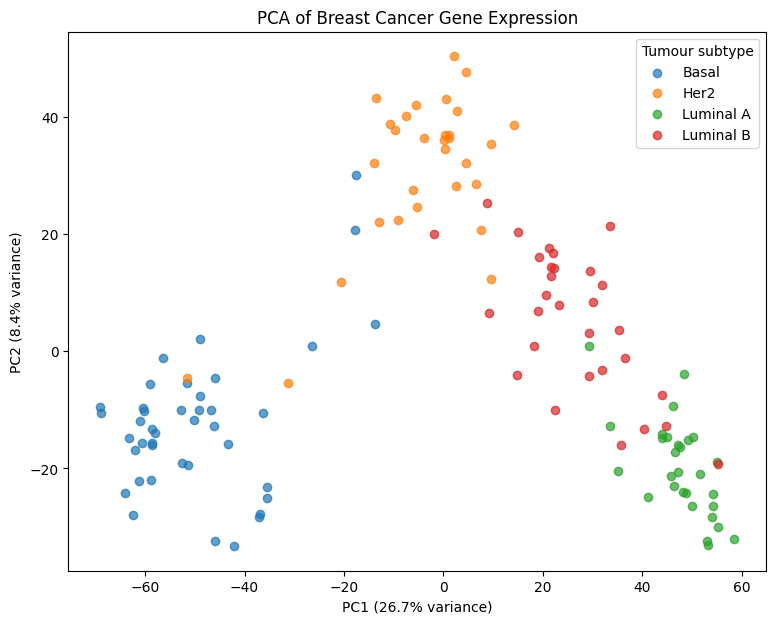

In [45]:
plt.figure(figsize=(9, 7))

for subtype in tumour_subtypes: #repeats the process for plotting each subtype
    subset = pca_df[pca_df["Subtype"] == subtype] #then temporarily selects only that subtype scatters it onto the 2D graph by running the below scatter function

    plt.scatter( #plots each tumour subtype as a point using its PC1 and PC2 coordinates
        subset["PC1"],
        subset["PC2"],
        label=subtype,
        alpha=0.7
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)") #so each variance reads as a percentage
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of Breast Cancer Gene Expression")
plt.legend(title="Tumour subtype")
plt.show()

The results showed clear differences in gene experience (measured by PC1 and PC2 principal components) between breast cancer subtypes particularly for Basal, HER2 and Luminal A, while Luminal B showed some overlap with Luminal A.

A limitation of this analysis was that although PCA can show patterns in the data, it does not identify which individual genes cause the differences between subtypes or whether those differences are statistically signficant.

Further analysis could include mapping probe sets to genes (so we know which individual genes cause the difference between subtypes), differential gene expression analysis and pathway analysis.
